In [2]:
#from ucimlrepo import fetch_ucirepo, list_available_datasets
# fetch dataset 
#nursery = fetch_ucirepo(id=76) 

In [3]:
## Imporat relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_extraction import DictVectorizer
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import roc_curve, auc
from sklearn import tree
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import RocCurveDisplay
from sklearn.model_selection import cross_val_score

In [4]:
# Get full dataset (features + target together)
df = pd.read_csv('nursery.csv')

print(df.shape)
df

(12960, 9)


,parents,has_nurs,form,children,housing,finance,social,health,final evaluation
0,usual,proper,complete,1,convenient,convenient,nonprob,recommended,recommend
1,usual,proper,complete,1,convenient,convenient,nonprob,priority,priority
2,usual,proper,complete,1,convenient,convenient,nonprob,not_recom,not_recom
3,usual,proper,complete,1,convenient,convenient,slightly_prob,recommended,recommend
4,usual,proper,complete,1,convenient,convenient,slightly_prob,priority,priority
...,...,...,...,...,...,...,...,...,...
12955,great_pret,very_crit,foster,more,critical,inconv,slightly_prob,priority,spec_prior
12956,great_pret,very_crit,foster,more,critical,inconv,slightly_prob,not_recom,not_recom
12957,great_pret,very_crit,foster,more,critical,inconv,problematic,recommended,spec_prior
12958,great_pret,very_crit,foster,more,critical,inconv,problematic,priority,spec_prior


### EDA

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12960 entries, 0 to 12959
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   parents           12960 non-null  object
 1   has_nurs          12960 non-null  object
 2   form              12960 non-null  object
 3   children          12960 non-null  object
 4   housing           12960 non-null  object
 5   finance           12960 non-null  object
 6   social            12960 non-null  object
 7   health            12960 non-null  object
 8   final evaluation  12960 non-null  object
dtypes: object(9)
memory usage: 911.4+ KB


In [6]:
df.shape

(12960, 9)

In [7]:
### Check missing values
df.isnull().sum()

parents             0
has_nurs            0
form                0
children            0
housing             0
finance             0
social              0
health              0
final evaluation    0
dtype: int64

In [8]:
## Unique values per column
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

parents: 3 unique values
has_nurs: 5 unique values
form: 4 unique values
children: 4 unique values
housing: 3 unique values
finance: 2 unique values
social: 3 unique values
health: 3 unique values
final evaluation: 5 unique values


In [9]:
df['final evaluation'].value_counts(normalize=True)

final evaluation
not_recom     0.333333
priority      0.329167
spec_prior    0.312037
very_recom    0.025309
recommend     0.000154
Name: proportion, dtype: float64

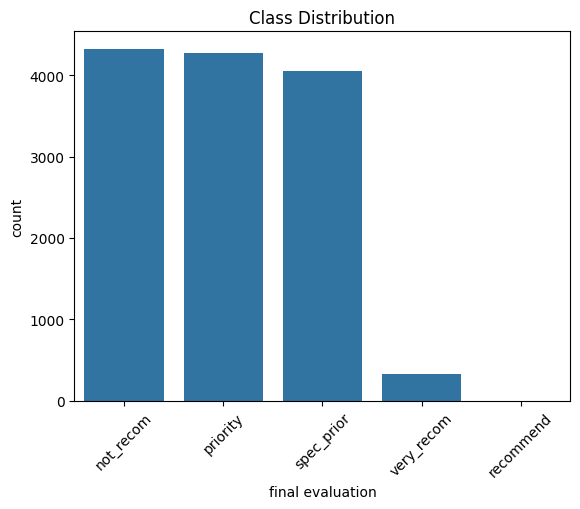

In [10]:
sns.countplot(data=df, x='final evaluation', order=df['final evaluation'].value_counts().index)
plt.title('Class Distribution')
plt.xticks(rotation=45)
plt.show()

In [11]:
df['final evaluation'] = df['final evaluation'].replace({'recommend': 'very_recom'}) # Merge recommend and very_recom

In [12]:
df['final evaluation'].value_counts(normalize=True)

final evaluation
not_recom     0.333333
priority      0.329167
spec_prior    0.312037
very_recom    0.025463
Name: proportion, dtype: float64

In [13]:
for col in df.columns:
    print(f"Column: {col}")
    print(f"Unique values ({df[col].nunique()}): {df[col].unique()}")
    print(df[col].value_counts())  # proportion of each category
    print("-"*40)


Column: parents
Unique values (3): ['usual' 'pretentious' 'great_pret']
parents
usual          4320
pretentious    4320
great_pret     4320
Name: count, dtype: int64
----------------------------------------
Column: has_nurs
Unique values (5): ['proper' 'less_proper' 'improper' 'critical' 'very_crit']
has_nurs
proper         2592
less_proper    2592
improper       2592
critical       2592
very_crit      2592
Name: count, dtype: int64
----------------------------------------
Column: form
Unique values (4): ['complete' 'completed' 'incomplete' 'foster']
form
complete      3240
completed     3240
incomplete    3240
foster        3240
Name: count, dtype: int64
----------------------------------------
Column: children
Unique values (4): ['1' '2' '3' 'more']
children
1       3240
2       3240
3       3240
more    3240
Name: count, dtype: int64
----------------------------------------
Column: housing
Unique values (3): ['convenient' 'less_conv' 'critical']
housing
convenient    4320
less_conv 

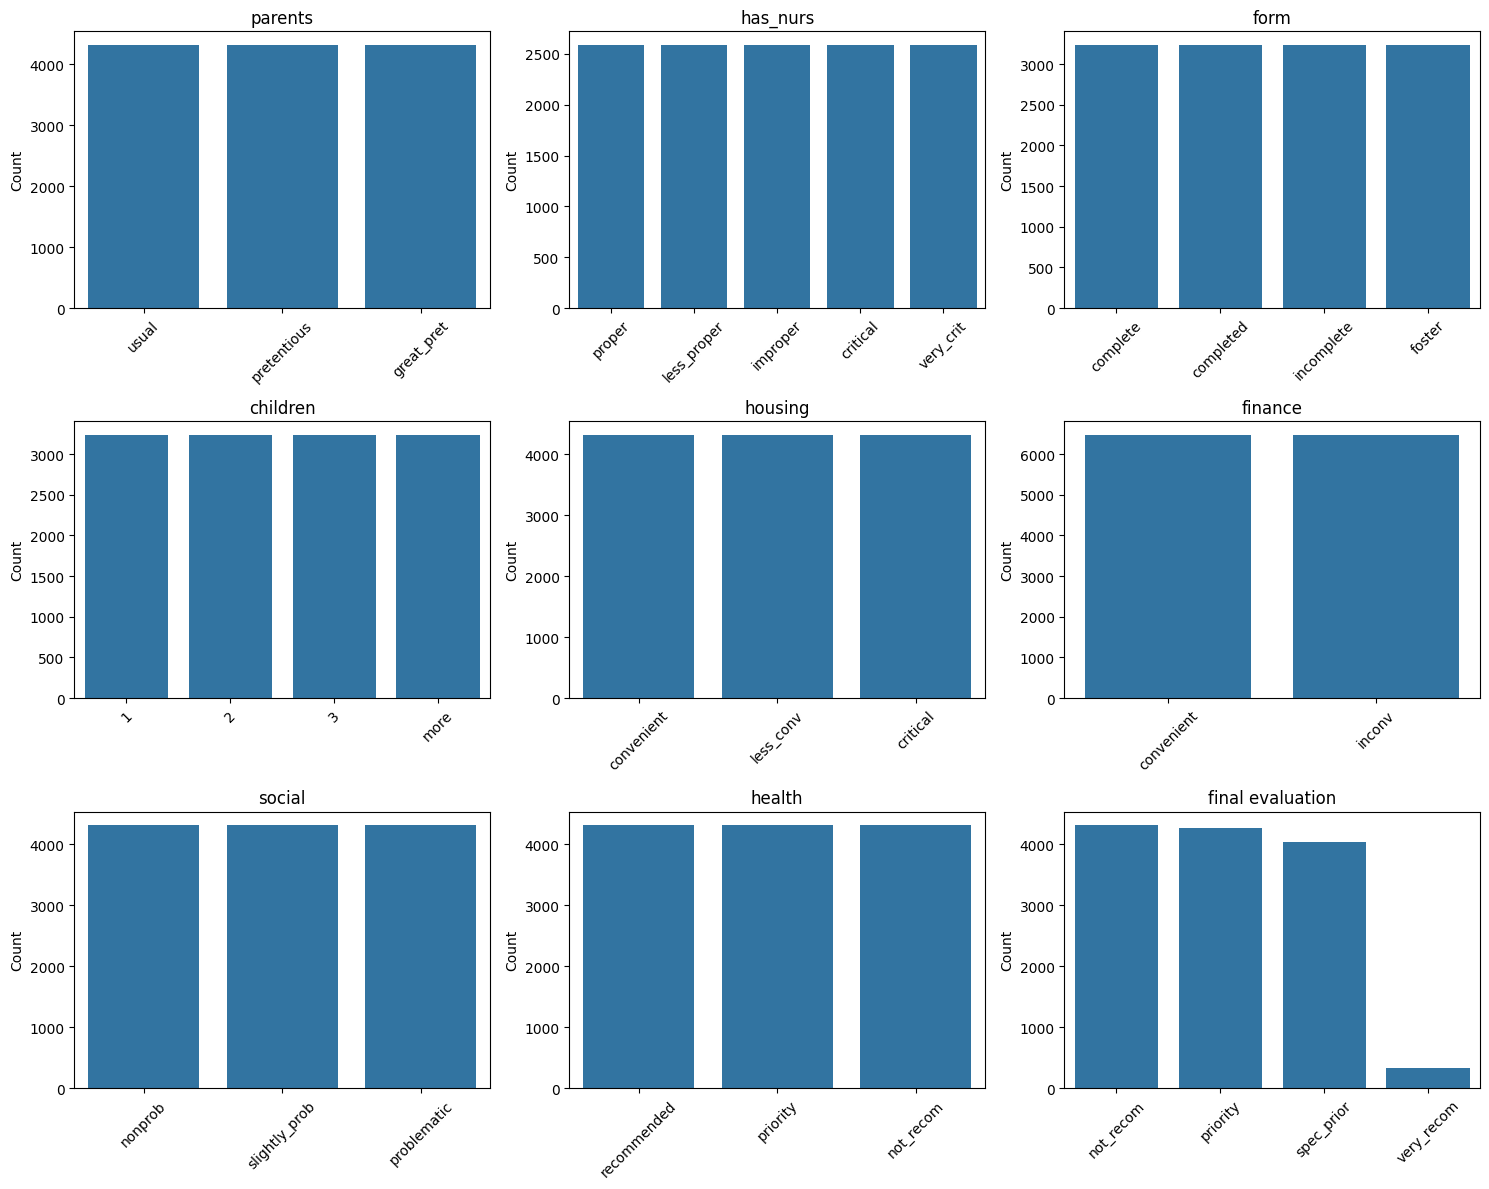

In [14]:
cols = df.columns
n_cols = 3
n_rows = (len(cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 12))

for i, col in enumerate(cols):
    ax = axes[i // n_cols, i % n_cols]
    sns.countplot(data=df, x=col, order=df[col].value_counts().index, ax=ax)
    ax.set_title(f"{col}")
    ax.set_xlabel("")
    ax.set_ylabel("Count")
    ax.tick_params(axis='x', rotation=45)

# Hide empty subplots if any
for j in range(i + 1, n_rows * n_cols):
    fig.delaxes(axes.flatten()[j])

plt.tight_layout()
plt.show()


In [15]:
# Train /test/validation split
from sklearn.model_selection import train_test_split
df_full_train , df_test = train_test_split(df, test_size = 0.2, random_state = 11)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state =11)

In [16]:
df_train = df_train.reset_index(drop =True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [17]:
len(df_train), len(df_val), len(df_test)

(7776, 2592, 2592)

In [18]:
# Separate features 
df_train_f = df_train.drop('final evaluation', axis=1)
df_val_f = df_val.drop('final evaluation', axis=1)
df_test_f = df_test.drop('final evaluation', axis=1)

In [19]:
## Target Features
y_train = df_train['final evaluation']
y_val = df_val['final evaluation']
y_test = df_test['final evaluation']

In [20]:
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_val = le.transform(y_val)
y_test = le.transform(y_test)

print(le.classes_)   # shows mapping like ['not_recom', 'priority', 'spec_prior', 'very_recom']

['not_recom' 'priority' 'spec_prior' 'very_recom']


### Logistic Regression Model

In [21]:
dv = DictVectorizer(sparse = False)
X_train = dv.fit_transform(df_train_f.to_dict(orient='records'))
X_val = dv.transform(df_val_f.to_dict(orient='records'))
X_test = dv.transform(df_test_f.to_dict(orient='records'))

In [22]:
log = LogisticRegression(max_iter=1000)
log.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [23]:
val_dicts = df_val.to_dict(orient = 'records')
X_val = dv.transform(val_dicts)

In [24]:
y_pred = log.predict_proba(X_val)
roc_auc = roc_auc_score(y_val, y_pred, multi_class='ovr')


print("ROC-AUC score:", roc_auc)


ROC-AUC score: 0.9899124365591939


In [25]:
import pickle, joblib
# save the model using pickle
joblib.dump(log, 'models/logistic_model.pkl')
joblib.dump(dv, 'models/dv.pkl')

print("Model and vectorizer saved successfully.")

Model and vectorizer saved successfully.


In [26]:
import pickle

In [27]:
output = f'logisticmodel.bin'
output

'logisticmodel.bin'

In [28]:
f_out = open(output, 'wb')
pickle.dump((dv, log), f_out)
f_out.close() # close it mandatory

In [29]:
with open(output, 'wb') as f_out:
    pickle.dump((dv, log), f_out)

### Load the Model

In [30]:
import pickle

In [31]:
model_file = 'logisticmodel.bin'

In [32]:
with open(output, 'rb') as f_in:
    dv, log = pickle.load(f_in)

In [33]:
dv, log

(DictVectorizer(sparse=False), LogisticRegression(max_iter=1000))

In [34]:
## test the model with new data
new_data = {
    'parents':'usual', 
    'has_nurs':'proper', 
    'form':'completed',
    'children':3,
    'housing':'convenient', 
    'finance':'convenient',
    'social':'slightly_prob', 
    'health':'priority'
}

In [35]:
X = dv.transform([new_data])

In [36]:
log.predict_proba(X)[0, 1]

np.float64(0.9819310378764359)

In [37]:
df['final evaluation'].unique()

array(['very_recom', 'priority', 'not_recom', 'spec_prior'], dtype=object)